In [1]:
import sys
sys.path.insert(0, '/home/sbaldasty/code/github/sbaldasty/noisy-values')

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from sympy.stats import Exponential
from sympy.stats import Normal
from main import NoisyValue

Eventually histograms should be part of the library proper. It should be really easy to make a histogram.

In [2]:
def histogram(v):
    samples = v.sample_n(1000)
    print(f"Mean: {samples.mean()}, Std: {samples.std()}")
    plt.hist(samples, bins=20, density=True)
    plt.title(f'Histogram of samples for NoisyValue')
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.show()

Handles non-Gaussian distributions. And the distributions don't have to be the same.

theta_0*theta_1
Mean: 0.6419549508629859, Std: 1.3501848694629277


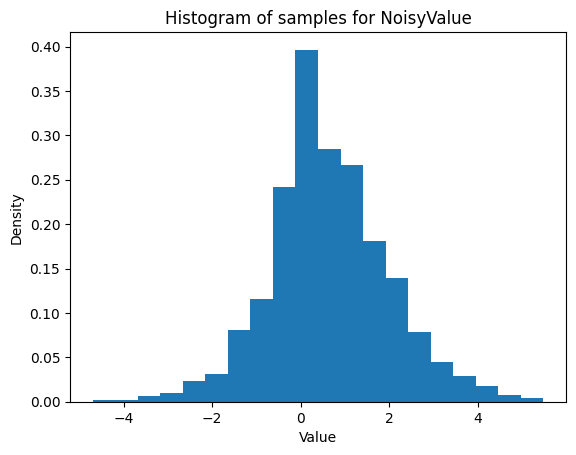

In [3]:
x = NoisyValue.from_distribution(0.5, Normal, 0, 1)
y = NoisyValue.from_distribution(1, Exponential, 2)

z = x * y

print(z.expr)
histogram(z)

Why are all those thetas necessary? Here's an example.

Mean: 1.361665329437805, Std: 22.64183450840913


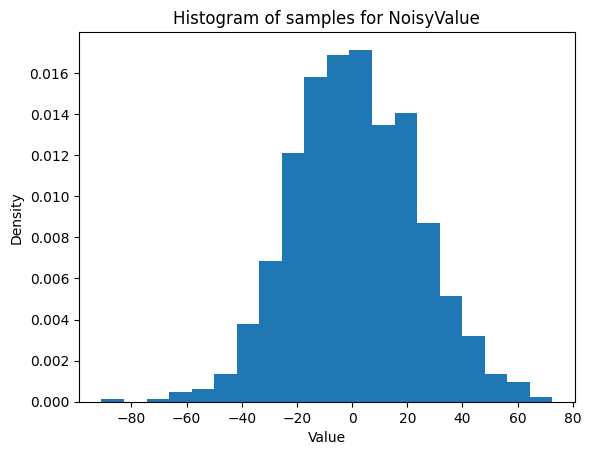

Mean: -24.93651644485453, Std: 52.32349349350419


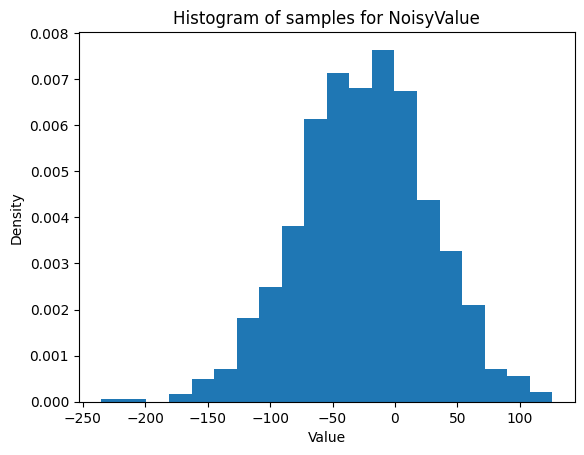

In [4]:
a = NoisyValue.from_distribution(10, Normal, 0, 10)
b = NoisyValue.from_distribution(10, Normal, 0, 10)
c = NoisyValue.from_distribution(10, Normal, 0, 10)
d = NoisyValue.from_distribution(10, Normal, 0, 10)
e = NoisyValue.from_distribution(10, Normal, 0, 10)

sum1 = a + b + c + d + e
sum2 = a + a + a + a + a

histogram(sum1)
histogram(sum2)

{'ax': <Axes: title={'center': 'Confidence-Interval Threshold Heatmap'}, xlabel='True value', ylabel='Observed value'>,
 'heat': array([[0.81731281, 0.81145138, 0.80459536, ..., 1.        , 1.        ,
         1.        ],
        [0.8173021 , 0.81144936, 0.80433138, ..., 1.        , 1.        ,
         1.        ],
        [0.79047482, 0.7845218 , 0.77689509, ..., 1.        , 1.        ,
         1.        ],
        ...,
        [1.        , 1.        , 1.        , ..., 0.74146397, 0.75367282,
         0.76034462],
        [1.        , 1.        , 1.        , ..., 0.74642899, 0.75368694,
         0.76762676],
        [1.        , 1.        , 1.        , ..., 0.74654835, 0.75377687,
         0.76763517]], shape=(201, 201)),
 'theta_grid': array([-6.13271171e+01, -6.07016894e+01, -6.00762618e+01, -5.94508341e+01,
        -5.88254065e+01, -5.81999788e+01, -5.75745511e+01, -5.69491235e+01,
        -5.63236958e+01, -5.56982682e+01, -5.50728405e+01, -5.44474129e+01,
        -5.38219852e+

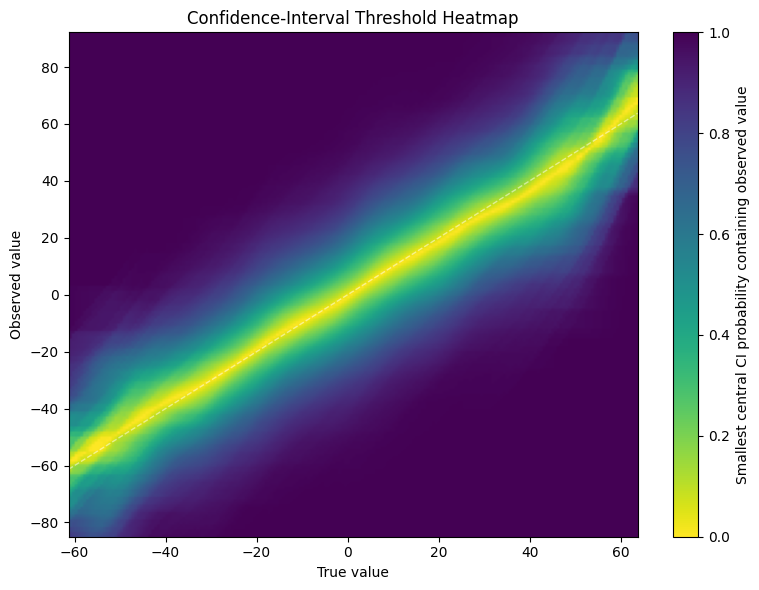

In [6]:

from main import plot_confidence_heatmap

plot_confidence_heatmap(sum1)

{'ax': <Axes: title={'center': 'Confidence-Interval Threshold Heatmap'}, xlabel='True value', ylabel='Observed value'>,
 'heat': array([[0.90993034, 0.92202969, 0.93680411, ..., 1.        , 1.        ,
         1.        ],
        [0.90564446, 0.8971383 , 0.91064486, ..., 1.        , 1.        ,
         1.        ],
        [0.86712179, 0.89606967, 0.88873708, ..., 1.        , 1.        ,
         1.        ],
        ...,
        [1.        , 1.        , 1.        , ..., 0.78604144, 0.78570685,
         0.78652851],
        [1.        , 1.        , 1.        , ..., 0.78922497, 0.78830722,
         0.78853492],
        [1.        , 1.        , 1.        , ..., 0.80369053, 0.80338995,
         0.80489879]], shape=(201, 201)),
 'theta_grid': array([-166.9686018 , -165.53667965, -164.1047575 , -162.67283535,
        -161.2409132 , -159.80899105, -158.3770689 , -156.94514674,
        -155.51322459, -154.08130244, -152.64938029, -151.21745814,
        -149.78553599, -148.35361384, -146.92

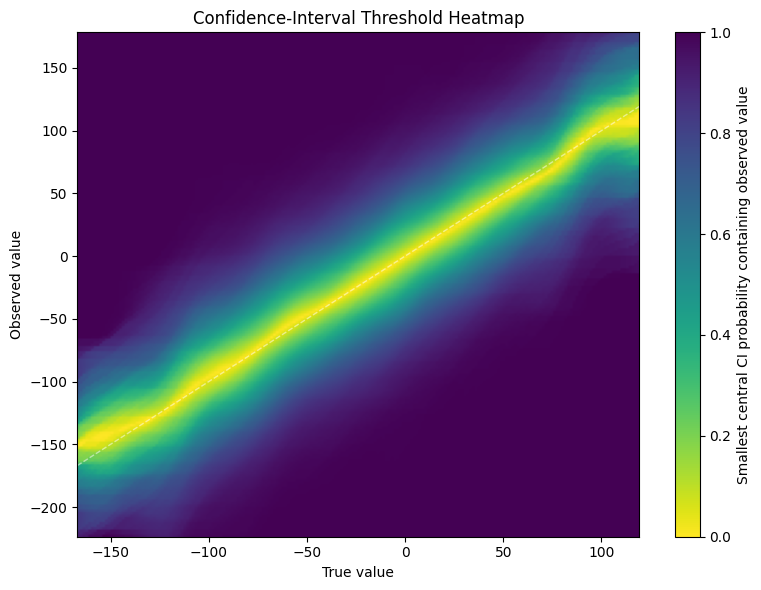

In [7]:
plot_confidence_heatmap(sum2)